# Paper Plots from Exported Data

This notebook imports exported results from:
- `results/main_export.npz`
- `results/dimless_export.npz`

and generates two publication-oriented figures with shared style settings.

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

In [2]:
# =============================================================================
# GLOBAL PLOTTING STYLE (EDIT HERE)
# =============================================================================
import os

OUT_DIR_WIN = 'figures'  # local folder (was an absolute Overleaf path)
OUT_DIR_DOCKER = '/overleaf_figures'

def resolve_output_dir(path_win, path_docker):
    if os.name == 'nt':
        return path_win

    # In Docker, enforce explicit mount to avoid silent saves to the wrong place.
    if os.path.isdir(path_docker):
        return path_docker

    raise RuntimeError(
        f"Output directory is not mounted in the container: {path_docker}. "
        "Restart the container using start_fenics.ps1 so the Overleaf folder is mounted."
    )

OUT_DIR = resolve_output_dir(OUT_DIR_WIN, OUT_DIR_DOCKER)
print(f'Saving figures to: {OUT_DIR}')

STYLE = {
    # A4 page-width friendly sizes
    'fig1_size': (8.27, 3.9),     # 1x2 static plot (wider, less cramped)
    'fig2_size': (8.9, 4.8),      # wider Figure 2 for cleaner labels
    'dpi': 300,

    # Typography (paper-friendly)
    'label_fs': 11,
    'fig2_label_fs': 9.5,
    'tick_fs': 10,
    'legend_fs': 8,
    'panel_fs': 11,

    # Markers/lines
    'marker_size': 20,
    'edge_lw': 0.5,
    'line_lw': 1.8,
    'mode_lw': 1.0,

    # Colors
    'analytical_color': 'black',
    'marker_edge_color': 'black',
    'marker_face_color': '0.5',  # medium light gray
    
    # Marker opacity
    'marker_alpha': 1,

    # Optional reference line in Figure 1b
    'plot_theta_ref': True,
    'theta_ref_val': 1/32,  # corresponds to x_{f0}/r = 1/4 (since theta = 1/2*(xf0/r)^2)
    'theta_ref_color': 'gray',

    # Legend positions (Figure 1)
    'legend_a_loc': 'upper left',
    'legend_a_anchor': (0.0, 0.88),
    'legend_b_loc': 'lower left',

    # Legend fontsize (Figure 2)
    'legend_fs': 10,

    # Output files
    'out_plot1': os.path.join(OUT_DIR, 'paper_plot_static_1x2.png'),
    'out_plot2': os.path.join(OUT_DIR, 'paper_plot_frf_2x2.png')
}

plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['STIX Two Text', 'Libertinus Serif', 'DejaVu Serif'],
    'mathtext.fontset': 'stix',
    'font.size': STYLE['tick_fs'],
    'axes.labelsize': STYLE['label_fs'],
    'legend.fontsize': STYLE['legend_fs'],
    'xtick.labelsize': STYLE['tick_fs'],
    'ytick.labelsize': STYLE['tick_fs']
})

Saving figures to: /overleaf_figures


In [3]:
# =============================================================================
# LOAD EXPORTED DATA
# =============================================================================
main_path = 'results/main_export.npz'
dimless_path = 'results/dimless_export.npz'

if not os.path.exists(main_path):
    raise FileNotFoundError(
        f'Missing file: {main_path}. Run beam_MAIN.ipynb (export cell) first.')

main = np.load(main_path, allow_pickle=True)

# dimless_export is OPTIONAL (it comes from the gravity-sweep study and is only
# needed for the colleague's Figure 2). The cable plots do not require it.
if os.path.exists(dimless_path):
    dimless = np.load(dimless_path, allow_pickle=True)
else:
    dimless = None

print('Loaded:')
print('  -', main_path)
print('  -', dimless_path if dimless is not None else f'{dimless_path} (not found - skipping dimless figures)')

Loaded:
  - results/main_export.npz
  - results/dimless_export.npz


In [4]:
# =============================================================================
# RECOMPUTE DIMENSIONLESS NUMBERS (FORMULAS EXPLICITLY DEFINED HERE)
# =============================================================================
# ---- MAIN EXPORT (point-wise arrays) ----
L_m = main['length']
r_m = main['radius']
E_m = main['E_mod']
rho_m = main['rho']
g_m = main['g']
A_m = main['A']
I_m = main['I']
eff_static_pct = 100.0 * main['static_efficiency']
defl_ratio_main = main['deflection_ratio']
start_main = main['start_condition'].astype(str)

# Pi2 for subplot (a):  Pi2 = rho*A*g*L^3/(4*pi^4*E*I)
pi2_main = (rho_m * A_m * g_m * L_m**3) / (4.0 * np.pi**4 * E_m * I_m)

# Pi (Theta) for subplot (b):  Theta = 0.5*(rho*A*g*L^4/(4*pi^4*E*I*r))^2
pi_main = 0.5 * ((rho_m * A_m * g_m * L_m**4) / (4.0 * np.pi**4 * E_m * I_m * r_m))**2

print('Main points:', len(pi_main))

# ---- DIMLESS EXPORT (FRF matrices) - only if available ----
if dimless is not None:
    L_d = float(dimless['length'])
    r_d = float(dimless['radius'])
    E_d = float(dimless['E_mod'])
    rho_d = float(dimless['rho'])
    g_d = dimless['g_values']
    A_d = float(dimless['A'])
    I_d = float(dimless['I'])

    frequencies = dimless['frequencies']
    frf_eff_amp = dimless['strain_efficiency_amp']
    frf_eff_phase = dimless['strain_efficiency_phase']
    frf_mid_amp = dimless['midpoint_disp_amp']
    frf_mid_phase = dimless['midpoint_disp_phase']
    mode2_straight = dimless['mode2_straight_hz']
    mode2_prebent = dimless['mode2_prebent_hz']

    pi_frf = 0.5 * ((rho_d * A_d * g_d * L_d**4) / (4.0 * np.pi**4 * E_d * I_d * r_d))**2
    print('FRF parameter sets:', len(pi_frf), ' | FRF shape:', frf_eff_amp.shape)
else:
    print('dimless_export not loaded -> Figure 2 (dimless FRF) will be skipped.')

Main points: 56
FRF parameter sets: 5  | FRF shape: (5, 120)


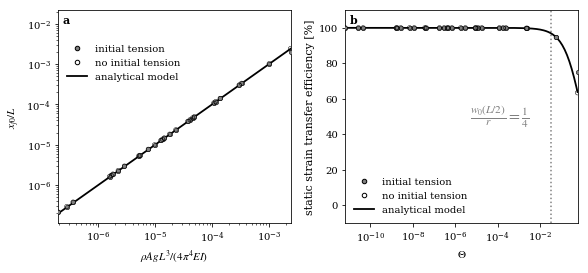

✓ Saved: /overleaf_figures/paper_plot_static_1x2.png


In [5]:
# =============================================================================
# FIGURE 1 (1x2): STATIC PLOTS
# (a) x_{f0}/L vs rho*A*g*L^3/(8*pi^4*E*I)
# (b) static efficiency vs Theta
# =============================================================================
fig, axes = plt.subplots(1, 2, figsize=STYLE['fig1_size'])

# Split by start condition
mask_tension = start_main == 'start_straight'      # filled
mask_no_tension = start_main == 'start_relaxed'    # empty

# -------------------- subplot (a) --------------------
ax = axes[0]

# data points (smaller, gray, transparent)
ax.scatter(pi2_main[mask_tension], defl_ratio_main[mask_tension],
           s=STYLE['marker_size'], marker='o', facecolor=STYLE['marker_face_color'],
           edgecolor=STYLE['marker_edge_color'], linewidth=STYLE['edge_lw'],
           alpha=STYLE['marker_alpha'], zorder=3)
ax.scatter(pi2_main[mask_no_tension], defl_ratio_main[mask_no_tension],
           s=STYLE['marker_size'], marker='o', facecolor='none',
           edgecolor=STYLE['marker_edge_color'], linewidth=STYLE['edge_lw'],
           alpha=STYLE['marker_alpha'], zorder=3)

# analytical model line (black)
x_a = np.logspace(np.log10(np.nanmin(pi2_main)), np.log10(np.nanmax(pi2_main)), 200)
y_a = x_a
ax.plot(x_a, y_a, color=STYLE['analytical_color'], linewidth=STYLE['line_lw'],
        label='analytical model', zorder=2)

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'$\rho A g L^3/(4\pi^4 E I)$')
ax.set_ylabel(r'$x_{f0}/L$')
ax.grid(False)

ax.text(0.02, 0.98, 'a', transform=ax.transAxes, fontsize=STYLE['panel_fs'],
        fontweight='bold', va='top', ha='left')

# Strict x-range to data min/max (no extra x-space)
ax.set_xlim(np.nanmin(pi2_main), np.nanmax(pi2_main))
ax.margins(x=0)

# custom legend
handles_a = [
    Line2D([0], [0], marker='o', color='none', markerfacecolor=STYLE['marker_face_color'],
           markeredgecolor=STYLE['marker_edge_color'], markersize=4.5, alpha=STYLE['marker_alpha'],
           label='initial tension'),
    Line2D([0], [0], marker='o', color='none', markerfacecolor='none',
           markeredgecolor=STYLE['marker_edge_color'], markersize=4.5, alpha=STYLE['marker_alpha'],
           label='no initial tension'),
    Line2D([0], [0], color=STYLE['analytical_color'], linewidth=STYLE['line_lw'], label='analytical model')
]
ax.legend(handles=handles_a, loc=STYLE['legend_a_loc'], bbox_to_anchor=STYLE['legend_a_anchor'],
          frameon=False)

# -------------------- subplot (b) --------------------
ax = axes[1]

ax.scatter(pi_main[mask_tension], eff_static_pct[mask_tension],
           s=STYLE['marker_size'], marker='o', facecolor=STYLE['marker_face_color'],
           edgecolor=STYLE['marker_edge_color'], linewidth=STYLE['edge_lw'],
           alpha=STYLE['marker_alpha'], zorder=3)
ax.scatter(pi_main[mask_no_tension], eff_static_pct[mask_no_tension],
           s=STYLE['marker_size'], marker='o', facecolor='none',
           edgecolor=STYLE['marker_edge_color'], linewidth=STYLE['edge_lw'],
           alpha=STYLE['marker_alpha'], zorder=3)

# analytical model (black): efficiency = 100/(1+Theta)
x_b = np.logspace(np.log10(np.nanmin(pi_main)), np.log10(np.nanmax(pi_main)), 200)
y_b = 100.0 / (1.0 + x_b)
ax.plot(x_b, y_b, color=STYLE['analytical_color'], linewidth=STYLE['line_lw'],
        label='analytical model', zorder=2)

if STYLE.get('plot_theta_ref', False):
    ax.axvline(STYLE['theta_ref_val'], color=STYLE['theta_ref_color'], linestyle=':', zorder=1)
    # Adding text label directly to the left, vertically centered
    # We use a mix of data and axes transform to center perfectly on Y-axis
    ax.text(STYLE['theta_ref_val'] * 0.1, 0.5, r'$\frac{w_0(L/2)}{r} = \frac{1}{4}$',
            transform=ax.get_xaxis_transform(),
            color=STYLE['theta_ref_color'],
            va='center', ha='right',
            fontsize=16)

ax.set_xscale('log')
ax.set_xlabel(r'$\Theta$') # = 1/2(\rho A g L^4/(4\pi^4 E I r))^2$')
ax.set_ylabel('static strain transfer efficiency [%]')
ax.grid(False)

ax.text(0.02, 0.98, 'b', transform=ax.transAxes, fontsize=STYLE['panel_fs'],
        fontweight='bold', va='top', ha='left')

# Strict x-range to data min/max (no extra x-space)
ax.set_xlim(np.nanmin(pi_main), np.nanmax(pi_main))
ax.margins(x=0)

# Requested fixed y-range
ax.set_ylim(-10, 110)

handles_b = [
    Line2D([0], [0], marker='o', color='none', markerfacecolor=STYLE['marker_face_color'],
           markeredgecolor=STYLE['marker_edge_color'], markersize=4.5, alpha=STYLE['marker_alpha'],
           label='initial tension'),
    Line2D([0], [0], marker='o', color='none', markerfacecolor='none',
           markeredgecolor=STYLE['marker_edge_color'], markersize=4.5, alpha=STYLE['marker_alpha'],
           label='no initial tension'),
    Line2D([0], [0], color=STYLE['analytical_color'], linewidth=STYLE['line_lw'], label='analytical model')
]
ax.legend(handles=handles_b, loc=STYLE['legend_b_loc'], frameon=False)

fig.tight_layout()
os.makedirs(os.path.dirname(STYLE['out_plot1']), exist_ok=True)
fig.savefig(STYLE['out_plot1'], dpi=STYLE['dpi'], bbox_inches='tight')
plt.show()

print(f"✓ Saved: {STYLE['out_plot1']}")

/usr/lib/python3/dist-packages/matplotlib/figure.py:2022: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  warnings.warn("This figure includes Axes that are not compatible "


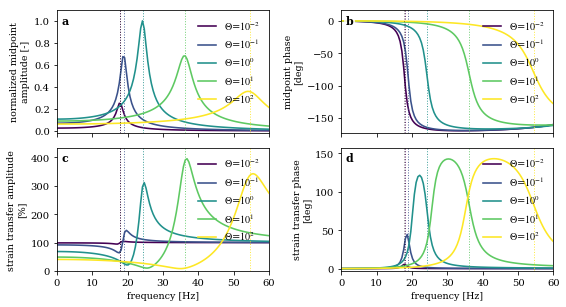

✓ Saved: /overleaf_figures/paper_plot_frf_2x2.png


In [6]:
if dimless is None:
    print('Figure 2 (dimless FRF) skipped: results/dimless_export.npz not found.')
else:
    # =============================================================================
    # FIGURE 2 (2x2): FREQUENCY RESPONSE COMBINATION
    # (a) midpoint amplitude (normalized)
    # (b) midpoint phase
    # (c) strain-eff amplitude
    # (d) strain-eff phase
    # =============================================================================
    # Sort by Theta for clean legend/color order
    sort_idx = np.argsort(pi_frf)
    theta_sorted = pi_frf[sort_idx]
    mid_amp_sorted = frf_mid_amp[sort_idx, :]
    mid_phase_sorted = frf_mid_phase[sort_idx, :]
    eff_amp_sorted = frf_eff_amp[sort_idx, :]
    eff_phase_sorted = frf_eff_phase[sort_idx, :]
    mode2_prebent_sorted = mode2_prebent[sort_idx]
    mode2_straight_sorted = mode2_straight[sort_idx]

    # Normalize midpoint amplitude so max over all curves/frequencies is 1
    global_mid_max = np.nanmax(np.abs(mid_amp_sorted))
    if np.isfinite(global_mid_max) and global_mid_max > 0:
        mid_amp_norm_sorted = mid_amp_sorted / global_mid_max
    else:
        mid_amp_norm_sorted = mid_amp_sorted.copy()

    def format_theta_power_label(theta_val):
        if not np.isfinite(theta_val) or theta_val <= 0:
            return r'$\Theta$=0'
        exp = int(np.round(np.log10(theta_val)))
        if np.isclose(theta_val, 10.0**exp, rtol=1e-3, atol=0.0):
            return rf'$\Theta$=$10^{{{exp}}}$'
        exp_floor = int(np.floor(np.log10(theta_val)))
        mant = theta_val / (10.0**exp_floor)
        return rf'$\Theta$={mant:.1f}$\times 10^{{{exp_floor}}}$'

    n_curves = len(theta_sorted)
    cmap = plt.cm.viridis
    colors = [cmap(i / max(1, n_curves - 1)) for i in range(n_curves)]

    fig, axes = plt.subplots(
        2, 2,
        figsize=STYLE['fig2_size'],
        sharex=True,
        gridspec_kw={'hspace': 0.12, 'wspace': 0.34}
     )
    ax_a, ax_b = axes[0, 0], axes[0, 1]
    ax_c, ax_d = axes[1, 0], axes[1, 1]

    for i in range(n_curves):
        c = colors[i]
        theta_label = format_theta_power_label(theta_sorted[i])

        # (a) Midpoint displacement amplitude normalized [-]
        ax_a.plot(frequencies, mid_amp_norm_sorted[i, :], color=c, linewidth=1.6, label=theta_label)

        # (b) Midpoint displacement phase [deg]
        ax_b.plot(frequencies, np.degrees(mid_phase_sorted[i, :]), color=c, linewidth=1.6, label=theta_label)

        # (c) Strain transfer efficiency amplitude [%]
        ax_c.plot(frequencies, eff_amp_sorted[i, :] * 100.0, color=c, linewidth=1.6, label=theta_label)

        # (d) Strain transfer efficiency phase [deg]
        ax_d.plot(frequencies, np.degrees(eff_phase_sorted[i, :]), color=c, linewidth=1.6, label=theta_label)

        # Vertical dotted mode-2 lines (pre-bent) in matching curve color
        f2_pre = mode2_prebent_sorted[i]
        if np.isfinite(f2_pre):
            ax_a.axvline(f2_pre, color=c, linestyle=':', linewidth=STYLE['mode_lw'], alpha=0.85)
            ax_b.axvline(f2_pre, color=c, linestyle=':', linewidth=STYLE['mode_lw'], alpha=0.85)
            ax_c.axvline(f2_pre, color=c, linestyle=':', linewidth=STYLE['mode_lw'], alpha=0.85)
            ax_d.axvline(f2_pre, color=c, linestyle=':', linewidth=STYLE['mode_lw'], alpha=0.85)

    # Optional straight-beam mode-2 reference line (black dotted)
    f2_straight = np.nanmean(mode2_straight_sorted)
    if np.isfinite(f2_straight):
        for ax in [ax_a, ax_b, ax_c, ax_d]:
            ax.axvline(f2_straight, color='black', linestyle=':', linewidth=STYLE['mode_lw'], alpha=0.45)

    # Labels (no titles, no gridlines)
    ax_a.set_ylabel('normalized midpoint\namplitude [-]', fontsize=STYLE['fig2_label_fs'])
    ax_b.set_ylabel('midpoint phase\n[deg]', fontsize=STYLE['fig2_label_fs'])
    ax_c.set_ylabel('strain transfer amplitude\n[%]', fontsize=STYLE['fig2_label_fs'])
    ax_d.set_ylabel('strain transfer phase\n[deg]', fontsize=STYLE['fig2_label_fs'])
    ax_c.set_xlabel('frequency [Hz]', fontsize=STYLE['fig2_label_fs'])
    ax_d.set_xlabel('frequency [Hz]', fontsize=STYLE['fig2_label_fs'])

    # Keep right-column y-labels on the left and tune padding to avoid center overlap
    ax_b.yaxis.set_label_position('left')
    ax_d.yaxis.set_label_position('left')
    ax_b.yaxis.tick_left()
    ax_d.yaxis.tick_left()
    ax_b.yaxis.labelpad = 3
    ax_d.yaxis.labelpad = 3

    # Strict x-range to data min/max for all subplots
    fmin, fmax = float(np.nanmin(frequencies)), float(np.nanmax(frequencies))
    for ax in [ax_a, ax_b, ax_c, ax_d]:
        ax.set_xlim(fmin, fmax)
        ax.margins(x=0)

    # Ensure panel labels avoid overlap with content by using a small white box
    label_bbox = dict(facecolor='white', edgecolor='none', alpha=0.8, pad=1.5)
    for ax, lab in zip([ax_a, ax_b, ax_c, ax_d], ['a', 'b', 'c', 'd']):
        ax.grid(False)
        ax.text(0.02, 0.96, lab, transform=ax.transAxes, fontsize=STYLE['panel_fs'],
                fontweight='bold', va='top', ha='left', bbox=label_bbox)
        ax.legend(loc='upper right', frameon=False, ncol=1, handlelength=1.8, fontsize=STYLE['legend_fs'])

    # Slight y-headroom to avoid panel-label overlap with highest content
    def add_headroom(ax, frac=0.08):
        y = []
        for line in ax.get_lines():
            if line.get_linestyle() != ':':
                y.extend(line.get_ydata())
        y = np.array(y, dtype=float)
        y = y[np.isfinite(y)]
        if y.size > 0:
            ymin, ymax = np.nanmin(y), np.nanmax(y)
            if ymax > ymin:
                ax.set_ylim(ymin - 0.02 * (ymax - ymin), ymax + frac * (ymax - ymin))

    # Apply automatic headroom to all panels
    add_headroom(ax_a, frac=0.10)
    add_headroom(ax_b, frac=0.10)
    add_headroom(ax_c, frac=0.10)
    add_headroom(ax_d, frac=0.10)

    fig.tight_layout(w_pad=1.0)
    os.makedirs(os.path.dirname(STYLE['out_plot2']), exist_ok=True)
    fig.savefig(STYLE['out_plot2'], dpi=STYLE['dpi'], bbox_inches='tight')
    plt.show()

    print(f"✓ Saved: {STYLE['out_plot2']}")
    if np.all(np.isnan(mode2_prebent_sorted)):
        print('Warning: all pre-bent mode-2 frequencies are NaN, so colored mode lines were not drawn.')

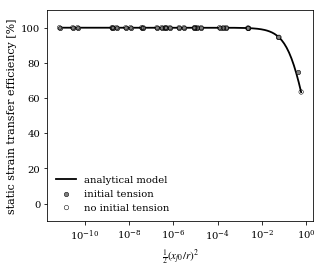

✓ Saved: /overleaf_figures/paper_plot_static_eff_vs_xf0r.png


In [7]:
# =============================================================================
# FIGURE 3: STATIC STRAIN TRANSFER EFFICIENCY VS 0.5*(x_f0/r)^2
# =============================================================================
# Compute x_f0 from the same static points used in Figure 1:
# defl_ratio_main = x_f0 / L  ->  x_f0 = defl_ratio_main * L
xf0_main = defl_ratio_main * L_m
theta_xf0 = 0.5 * (xf0_main / r_m) ** 2

# Recreate masks locally so this cell does not depend on Figure 1 execution
mask_tension = start_main == 'start_straight'      # filled
mask_no_tension = start_main == 'start_relaxed'    # empty

fig, ax = plt.subplots(figsize=(4.6, 3.9))

# Data points with same marker style convention as Figure 1
ax.scatter(theta_xf0[mask_tension], eff_static_pct[mask_tension],
           s=STYLE['marker_size'], marker='o', facecolor=STYLE['marker_face_color'],
           edgecolor=STYLE['marker_edge_color'], linewidth=STYLE['edge_lw'],
           alpha=STYLE['marker_alpha'], zorder=3, label='initial tension')
ax.scatter(theta_xf0[mask_no_tension], eff_static_pct[mask_no_tension],
           s=STYLE['marker_size'], marker='o', facecolor='none',
           edgecolor=STYLE['marker_edge_color'], linewidth=STYLE['edge_lw'],
           alpha=STYLE['marker_alpha'], zorder=3, label='no initial tension')

# Optional analytical reference: efficiency = 100 / (1 + 0.5*(x_f0/r)^2)
x_valid = theta_xf0[np.isfinite(theta_xf0) & (theta_xf0 > 0)]
if x_valid.size >= 2:
    x_line = np.logspace(np.log10(np.nanmin(x_valid)), np.log10(np.nanmax(x_valid)), 200)
    y_line = 100.0 / (1.0 + x_line)
    ax.plot(x_line, y_line, color=STYLE['analytical_color'], linewidth=STYLE['line_lw'],
            zorder=2, label='analytical model')
    ax.set_xscale('log')

ax.set_xlabel(r'$\frac{1}{2}(x_{f0}/r)^2$')
ax.set_ylabel('static strain transfer efficiency [%]')
ax.set_ylim(-10, 110)
ax.grid(False)
ax.legend(frameon=False)

fig.tight_layout()
out_plot3 = os.path.join(OUT_DIR, 'paper_plot_static_eff_vs_xf0r.png')
os.makedirs(os.path.dirname(out_plot3), exist_ok=True)
fig.savefig(out_plot3, dpi=STYLE['dpi'], bbox_inches='tight')
plt.show()

print(f"✓ Saved: {out_plot3}")

## Cable-specific plots

These figures use `cable_definitions.py` (`CABLE_COLORS`, `GAP_MARKERS`).
They read:
- `results/main_export.npz`  (static efficiency + natural frequencies, from `beam_MAIN.ipynb`)
- `results/cable_frf_export.npz`  (per-cable FRF, from the batch section of `hanging_beam_frequency_response.ipynb`)

Figures are saved to a local `figures/` folder.

In [8]:
# =============================================================================
# CABLE-SPECIFIC PLOTS: setup
# =============================================================================
from cable_definitions import CABLE_COLORS, GAP_MARKERS, GAP_LENGTHS
from matplotlib.lines import Line2D

FIG_DIR = 'figures'
os.makedirs(FIG_DIR, exist_ok=True)

if 'cable' not in main.files:
    raise RuntimeError("main_export.npz has no 'cable' field. Re-run the EXPORT "
                       "cell in beam_MAIN.ipynb (updated for the cable study).")

cable_main = main['cable'].astype(str)
gap_main   = main['gap'].astype(float)
start_c    = main['start_condition'].astype(str)
sag_cfg    = (main['sag_config'].astype(str) if 'sag_config' in main.files
              else np.full(len(cable_main), 'Sag Measured'))
eff_pct    = 100.0 * main['static_efficiency']
f1_pre     = main['f1_prebent'] if 'f1_prebent' in main.files else np.full(len(cable_main), np.nan)

# Theta (same definition as Figure 1b), recomputed from main
Theta_main = 0.5 * ((main['rho'] * main['A'] * main['g'] * main['length']**4)
                    / (4.0 * np.pi**4 * main['E_mod'] * main['I'] * main['radius']))**2

cables_present = [n for n in CABLE_COLORS if n in set(cable_main)]

def gap_marker(g):
    key = min(GAP_MARKERS, key=lambda kk: abs(kk - g))
    return GAP_MARKERS[key]

print('cables :', cables_present)
print('gaps   :', sorted(set(round(float(x), 3) for x in gap_main)))
print('starts :', sorted(set(start_c)))
print('sags   :', sorted(set(sag_cfg)))

cables : ['Cable1', 'Cable2', 'Cable3', 'Cable4', 'Cable5', 'Cable6', 'Cable7']
gaps   : [0.05, 0.1, 0.15, 0.2]
starts : ['start_relaxed', 'start_straight']
sags   : ['Sag Measured']


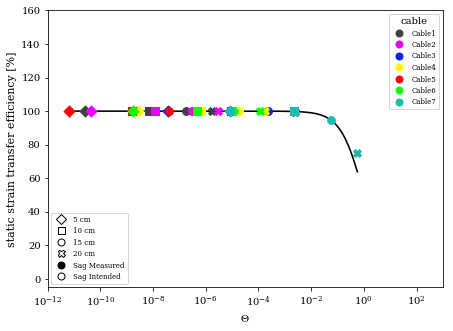

saved figures/cable_static_eff_vs_theta.png


In [9]:
# =============================================================================
# (Adapted scatter) static strain transfer efficiency vs Theta
#   colour = cable, marker = gap length, filled = Sag Measured, hollow = Sag Intended
#   (start_straight runs only)
# =============================================================================
fig, ax = plt.subplots(figsize=(6.4, 4.7))
for i in range(len(cable_main)):
    if start_c[i] != 'start_straight':
        continue  # show only the start_straight case; fill now encodes the sag round
    name = cable_main[i]
    col = CABLE_COLORS.get(name, 'gray')
    filled = (sag_cfg[i] == 'Sag Measured')
    ax.scatter(Theta_main[i], eff_pct[i],
               marker=gap_marker(float(gap_main[i])), s=60, linewidths=1.1,
               facecolor=col if filled else 'none', edgecolor=col, zorder=3)

xv = Theta_main[np.isfinite(Theta_main) & (Theta_main > 0)]
if xv.size >= 2:
    xl = np.logspace(np.log10(xv.min()), np.log10(xv.max()), 200)
    ax.plot(xl, 100.0 / (1.0 + xl), 'k-', lw=1.6, label=r'$100/(1+\Theta)$')
    ax.set_xscale('log')

ax.set_xlabel(r'$\Theta$')
ax.set_ylabel('static strain transfer efficiency [%]')
ax.set_ylim(-5, 160)
ax.set_xlim(1e-12, 1e3)


cable_handles = [Line2D([0], [0], marker='o', ls='none', markerfacecolor=CABLE_COLORS[n],
                        markeredgecolor=CABLE_COLORS[n], markersize=7, label=n)
                 for n in cables_present]
gap_handles = [Line2D([0], [0], marker=GAP_MARKERS[g], ls='none', color='k',
                      markerfacecolor='none', markersize=7, label=f'{int(round(g*100))} cm')
               for g in GAP_LENGTHS]
fill_handles = [Line2D([0], [0], marker='o', ls='none', color='k', markerfacecolor='k',
                       markersize=7, label='Sag Measured'),
                Line2D([0], [0], marker='o', ls='none', color='k', markerfacecolor='none',
                       markersize=7, label='Sag Intended')]
leg1 = ax.legend(handles=cable_handles, title='cable', fontsize=7, loc='upper right')
ax.add_artist(leg1)
ax.legend(handles=gap_handles + fill_handles, fontsize=7, loc='lower left')

fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'cable_static_eff_vs_theta.png'), dpi=300, bbox_inches='tight')
plt.show()
print('saved figures/cable_static_eff_vs_theta.png')

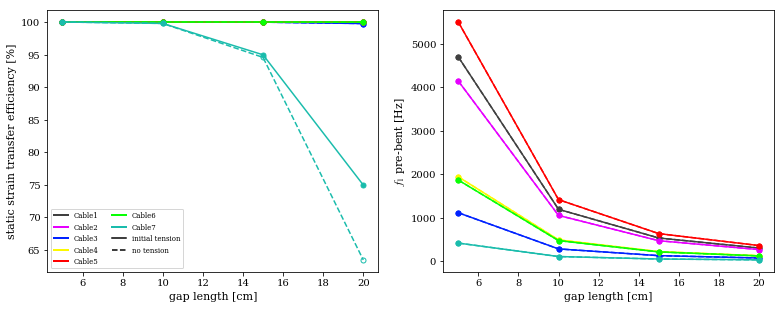

saved figures/cable_vs_gap.png


In [10]:
# =============================================================================
# (Per-cable comparison) efficiency and f1 vs gap length
#   solid + filled = initial tension (start_straight); dashed + open = no tension
# =============================================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.4))
for name in cables_present:
    c = CABLE_COLORS[name]
    for sc, ls, mfc in [('start_relaxed', '--', 'none'), ('start_straight', '-', c)]:
        m = (cable_main == name) & (start_c == sc)
        if not np.any(m):
            continue
        order = np.argsort(gap_main[m])
        gg = gap_main[m][order] * 100.0
        ax1.plot(gg, eff_pct[m][order], ls, color=c, marker='o', mfc=mfc, ms=5)
        ax2.plot(gg, f1_pre[m][order], ls, color=c, marker='o', mfc=mfc, ms=5)

ax1.set_xlabel('gap length [cm]'); ax1.set_ylabel('static strain transfer efficiency [%]')
ax2.set_xlabel('gap length [cm]'); ax2.set_ylabel(r'$f_1$ pre-bent [Hz]')
handles = [Line2D([0], [0], color=CABLE_COLORS[n], lw=2, label=n) for n in cables_present]
handles += [Line2D([0], [0], color='k', ls='-', label='initial tension'),
            Line2D([0], [0], color='k', ls='--', label='no tension')]
ax1.legend(handles=handles, fontsize=7, ncol=2)
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'cable_vs_gap.png'), dpi=300, bbox_inches='tight')
plt.show()
print('saved figures/cable_vs_gap.png')

In [11]:
# =============================================================================
# (Per-cable FRF) strain transfer efficiency amplitude & phase vs frequency
#   colour = cable, line style = gap length
# =============================================================================
frf_path = 'results/cable_frf_export.npz'
if not os.path.exists(frf_path):
    print('No results/cable_frf_export.npz found. Run the BATCH section in '
          'hanging_beam_frequency_response.ipynb first.')
else:
    cf = np.load(frf_path, allow_pickle=True)
    f = cf['frequencies']
    cs = cf['cables'].astype(str)
    gp = cf['gap'].astype(float)
    amp = cf['strain_efficiency_amp']
    ph = cf['strain_efficiency_phase']
    gap_ls = {0.05: ':', 0.10: '--', 0.15: '-'}

    fig, (axA, axP) = plt.subplots(1, 2, figsize=(12.5, 4.6))
    for k in range(len(cs)):
        c = CABLE_COLORS.get(cs[k], 'gray')
        ls = gap_ls.get(round(float(gp[k]), 2), '-')
        axA.plot(f, amp[k] * 100.0, color=c, ls=ls, lw=1.4)
        axP.plot(f, np.degrees(ph[k]), color=c, ls=ls, lw=1.4)
    axA.set_xlabel('frequency [Hz]'); axA.set_ylabel('strain transfer efficiency [%]')
    axP.set_xlabel('frequency [Hz]'); axP.set_ylabel('phase [deg]')
    axA.set_xlim(f.min(), f.max()); axP.set_xlim(f.min(), f.max())

    cs_present = [n for n in CABLE_COLORS if n in set(cs)]
    handles = [Line2D([0], [0], color=CABLE_COLORS[n], lw=2, label=n) for n in cs_present]
    handles += [Line2D([0], [0], color='k', ls=gap_ls.get(round(float(g), 2), '-'),
                       label=f'{int(round(float(g)*100))} cm') for g in sorted(set(gp))]
    axA.legend(handles=handles, fontsize=7, ncol=2)
    fig.suptitle(f"Per-cable frequency response (start = {str(cf['start_condition'])})")
    fig.tight_layout()
    fig.savefig(os.path.join(FIG_DIR, 'cable_frf.png'), dpi=300, bbox_inches='tight')
    plt.show()
    print('saved figures/cable_frf.png')

No results/cable_frf_export.npz found. Run the BATCH section in hanging_beam_frequency_response.ipynb first.
